# Notebook 4 - Evaluation & Model Comparison
**Owner:** Member 4

**Note:** This is a Regression project, not Classification.
We use R2, MAE, MSE, RMSE - not accuracy_score, since accuracy_score requires exact
matches and is not meaningful for continuous predictions. We treat **R2 as our "accuracy"**.


## 1. Import Libraries & Load Models + Test Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

linear_model = joblib.load("../models/linear_regression.pkl")
decision_tree_model = joblib.load("../models/decision_tree.pkl")
random_forest_model = joblib.load("../models/random_forest.pkl")

X_test = pd.read_csv("../data/processed/X_test.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Models and test data loaded successfully.")


Models and test data loaded successfully.


## 2. Evaluate Model 1 - Linear Regression

In [2]:
y_pred_lr = linear_model.predict(X_test_scaled)

print("Linear Regression")
print("R2  :", r2_score(y_test, y_pred_lr))
print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", mean_squared_error(y_test, y_pred_lr) ** 0.5)


Linear Regression
R2  : 0.8862045574393046
MAE : 2828.973747103939
RMSE: 4572.81123935467


## 3. Evaluate Model 2 - Decision Tree Regressor

In [3]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree")
print("R2  :", r2_score(y_test, y_pred_dt))
print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", mean_squared_error(y_test, y_pred_dt) ** 0.5)


Decision Tree
R2  : 0.8916833712530271
MAE : 2693.266420693201
RMSE: 4461.371691390971


## 4. Evaluate Model 3 - Random Forest Regressor

In [4]:
y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest")
print("R2  :", r2_score(y_test, y_pred_rf))
print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", mean_squared_error(y_test, y_pred_rf) ** 0.5)


Random Forest
R2  : 0.9011550741856774
MAE : 2414.52935034516
RMSE: 4261.848720693212


## 5. Comparison Table

In [5]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "R2": [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf)],
    "MAE": [mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_dt), mean_absolute_error(y_test, y_pred_rf)],
    "RMSE": [
        mean_squared_error(y_test, y_pred_lr) ** 0.5,
        mean_squared_error(y_test, y_pred_dt) ** 0.5,
        mean_squared_error(y_test, y_pred_rf) ** 0.5,
    ],
})
results


,Model,R2,MAE,RMSE
0,Linear Regression,0.886205,2828.973747,4572.811239
1,Decision Tree,0.891683,2693.266421,4461.371691
2,Random Forest,0.901155,2414.529350,4261.848721


## 6. Comparison Chart (R2 & RMSE side by side)

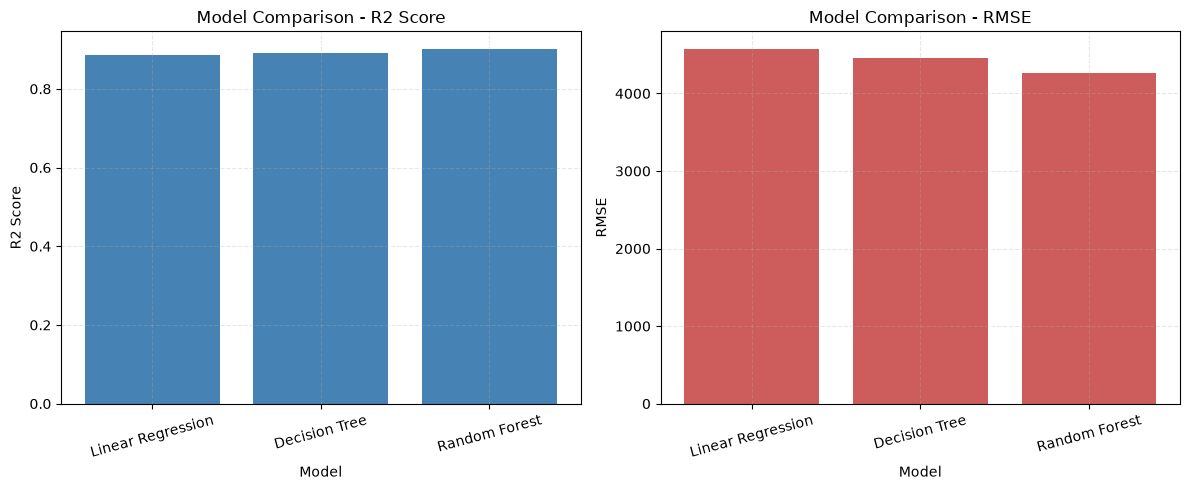

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["Model"], results["R2"], color="steelblue")
axes[0].set_title("Model Comparison - R2 Score")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("R2 Score")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.3)

axes[1].bar(results["Model"], results["RMSE"], color="indianred")
axes[1].set_title("Model Comparison - RMSE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Actual vs Predicted

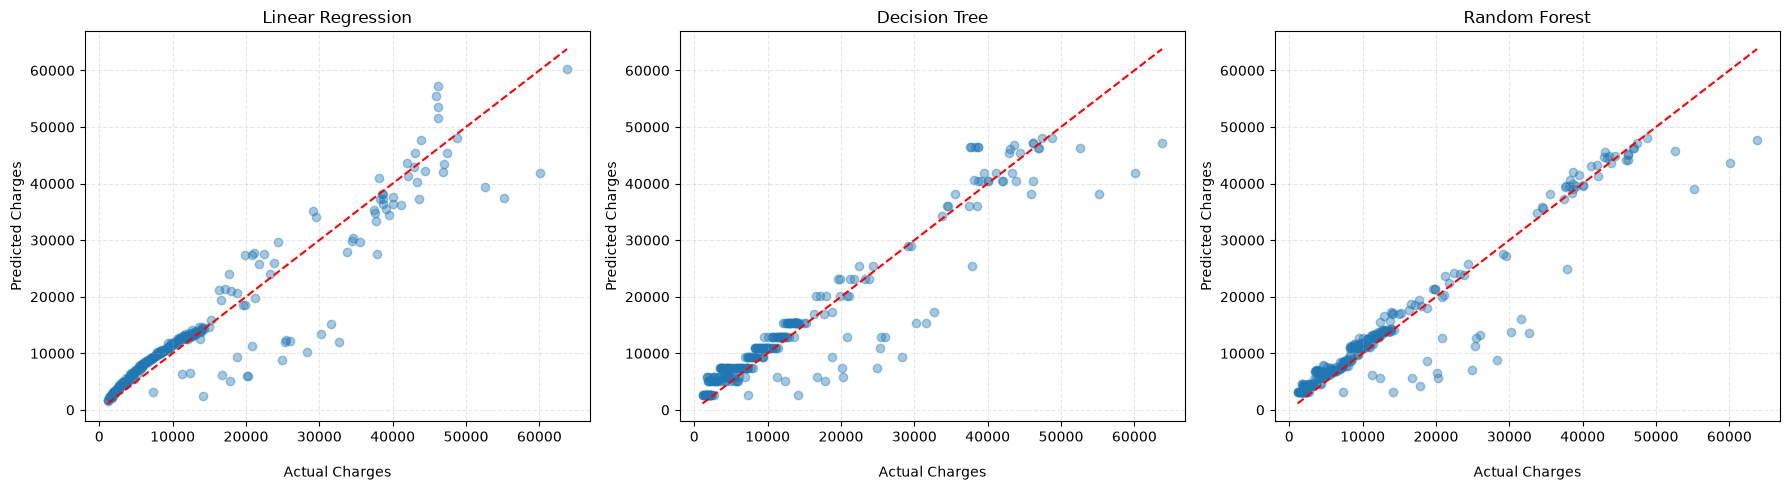

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
predictions = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
}

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_title(name)
    ax.set_xlabel("Actual Charges",labelpad=15)
    ax.set_ylabel("Predicted Charges")
    ax.grid(True, linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Residuals Analysis (Best Model)

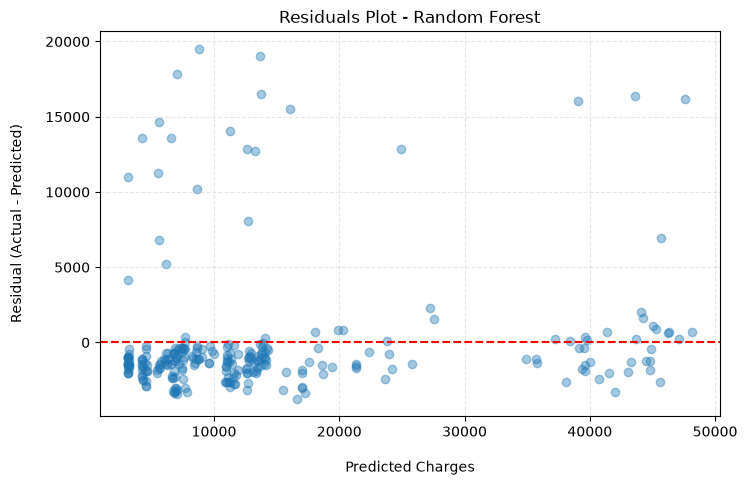

In [8]:
best_model_name = results.loc[results["R2"].idxmax(), "Model"]
best_pred = predictions[best_model_name]
residuals = y_test - best_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(best_pred, residuals, alpha=0.4)
ax.axhline(y=0, color="r", linestyle="--")
ax.set_title(f"Residuals Plot - {best_model_name}")
ax.set_xlabel("Predicted Charges",labelpad=15)
ax.set_ylabel("Residual (Actual - Predicted)",labelpad=15)
ax.grid(True, linestyle="--", alpha=0.3)
fig.savefig(f"{FIGURES_DIR}/residuals_best_model.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Final Model Selection

In [9]:
best_model_row = results.loc[results["R2"].idxmax()]
print("Best model based on R2:")
print(best_model_row)


Best model based on R2:
Model    Random Forest
R2            0.901155
MAE         2414.52935
RMSE       4261.848721
Name: 2, dtype: object


**Decision:** The selected model for deployment is the one with the highest R2 and lowest RMSE
shown above. This matches the EDA finding that `smoker` interacts strongly with `bmi` and `age` -
an interaction that tree-based models capture more naturally than Linear Regression.

## Deliverables - Member 4
- [x] Final comparison table
- [x] Charts saved in `reports/figures/` (comparison, actual vs predicted, residuals)
- [x] Best model identified (Section 9)
